# 02 — Data Collection

3 sumber data dikumpulkan terpisah (belum dibersihkan -- itu tahap
03_data_processing):
1. **Venue wisata OSM** (Overpass API) -- legal, gratis, lisensi ODbL.
2. **Hotel OSM** -- titik berangkat/pulang itinerary (next phase UI).
3. **Massive-STEPS-Jakarta** (HuggingFace) -- check-in nyata, sumber utama
   trajectory & popularitas (`checkin_count`), pelengkap OSM yang tidak
   punya data behavior pengguna.

In [1]:
import sys
sys.path.insert(0, "../..")

import pandas as pd
import matplotlib.pyplot as plt
import config

## 1. Venue wisata OSM

In [2]:
print("Boundary area:", config.JAKARTA_AREA_NAME, "(admin_level", config.JAKARTA_AREA_ADMIN_LEVEL, ")")
print("Filter kategori wisata OSM:")
for k, v in config.TOURISM_FILTERS.items():
    print(f"  {k}: {v}")

Boundary area: Daerah Khusus Ibukota Jakarta (admin_level 4 )
Filter kategori wisata OSM:
  tourism: ['attraction', 'museum', 'viewpoint', 'zoo', 'theme_park', 'gallery', 'artwork', 'aquarium']
  leisure: ['park', 'garden']
  historic: None
  amenity: ['place_of_worship', 'marketplace']


Jalankan harvest (uncomment, butuh internet ~2-3 menit) atau skip ke hasil
run sebelumnya:

In [3]:
# import os
# sys.path.insert(0, "../../01_data_collection")
# import collect_osm
# collect_osm.main()

In [4]:
raw = pd.read_csv("../../data/raw/venues_raw.csv")
print(f"Total venue OSM: {len(raw)}")
raw["venue_category"].value_counts().head(10)

Total venue OSM: 6166


venue_category
amenity:place_of_worship    5323
leisure:park                 392
amenity:marketplace          229
tourism:museum                39
tourism:attraction            37
tourism:artwork               24
historic:memorial             24
tourism:gallery               18
historic:monument             17
tourism:viewpoint             13
Name: count, dtype: int64

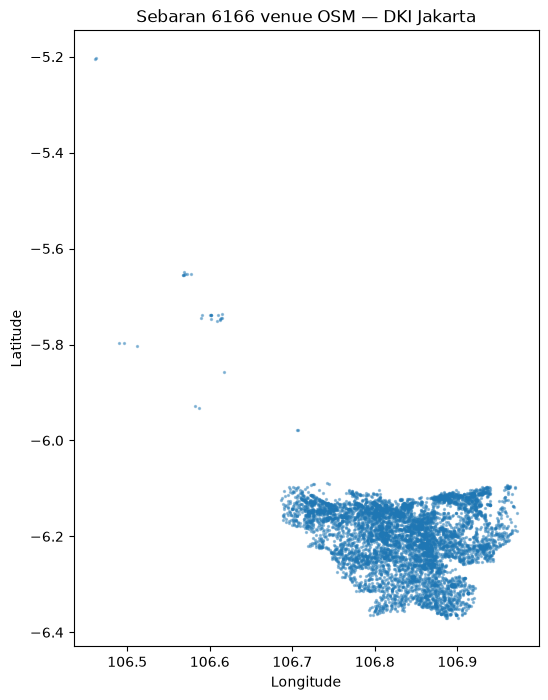

In [5]:
fig, ax = plt.subplots(figsize=(6, 8))
ax.scatter(raw["longitude"], raw["latitude"], s=2, alpha=0.4)
ax.set_title(f"Sebaran {len(raw)} venue OSM — DKI Jakarta")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

## 2. Hotel OSM (titik berangkat/pulang itinerary)

Dipisah dari venue wisata -- perannya beda (start/end point, bukan venue
yang diskor/direkomendasikan). Filter: `tourism=hotel/guest_house/hostel/apartment`.

In [6]:
hotels = pd.read_csv("../../data/raw/hotels_raw.csv")
print(f"Total hotel ditemukan: {len(hotels)}")
hotels[["name", "venue_category", "latitude", "longitude"]].head(10)

Total hotel ditemukan: 775

,name,venue_category,latitude,longitude
0,Alam Kotok - Island Resort,tourism:hotel,-5.700229,106.536739
1,Mercure Hotel Ancol,tourism:hotel,-6.122377,106.836569
2,The Dharmawangsa,tourism:hotel,-6.253360,106.805262
3,Tator,tourism:hotel,-6.185756,106.829183
4,Guest House,tourism:hostel,-6.183295,106.829747
5,Aston Rasuna,tourism:hotel,-6.219271,106.836534
6,kido hums,tourism:guest_house,-6.235442,106.926086
7,Wisma Shafir,tourism:guest_house,-5.747801,106.612007
8,The Westin Jakarta,tourism:hotel,-6.223806,106.833526
9,Antoni,tourism:hotel,-6.151083,106.817539


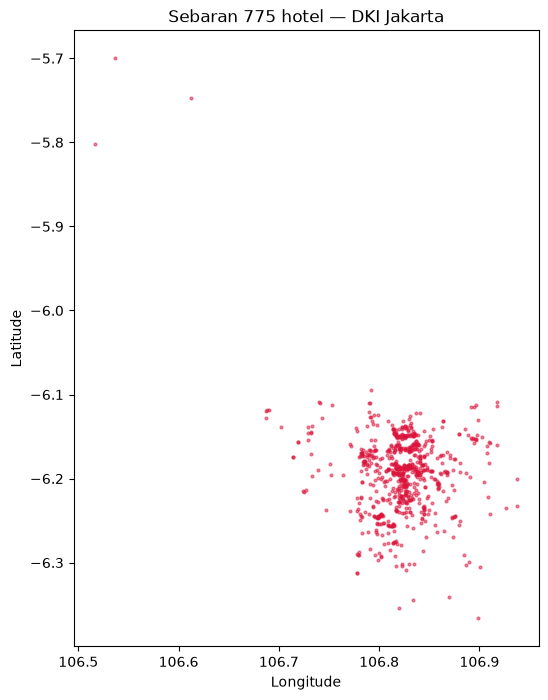

In [7]:
fig, ax = plt.subplots(figsize=(6, 8))
ax.scatter(hotels["longitude"], hotels["latitude"], s=4, alpha=0.5, color="crimson")
ax.set_title(f"Sebaran {len(hotels)} hotel — DKI Jakarta")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.show()

## 3. Massive-STEPS-Jakarta (check-in nyata)

Dataset penelitian publik (HuggingFace), berisi check-in nyata pengguna
Foursquare-style historis (2012-2018) -- bukan OSM, bukan simulasi.
`checkin_count` per venue jadi proxy popularitas **nyata**, pengganti
`unique_visitors` sintetis pada venue yang berhasil di-merge.

In [8]:
print(f"Repo: {config.STEPS_REPO_ID}")

Repo: CRUISEResearchGroup/Massive-STEPS-Jakarta


Jalankan download (uncomment, butuh internet) atau skip ke hasil run
sebelumnya:

In [9]:
# sys.path.insert(0, "../../01_data_collection")
# import collect_steps
# collect_steps.main()

In [10]:
checkins = pd.read_csv("../../data/raw/steps_checkins_raw.csv")
venues_steps = pd.read_csv("../../data/raw/steps_venues_raw.csv")
print(f"Total check-in (mentah): 412100")
print(f"Setelah drop null lat/lon/name: {len(checkins)}")
print(f"Venue unik (agregasi per venue_id): {len(venues_steps)}")

Total check-in (mentah): 412100
Setelah drop null lat/lon/name: 333191
Venue unik (agregasi per venue_id): 49291


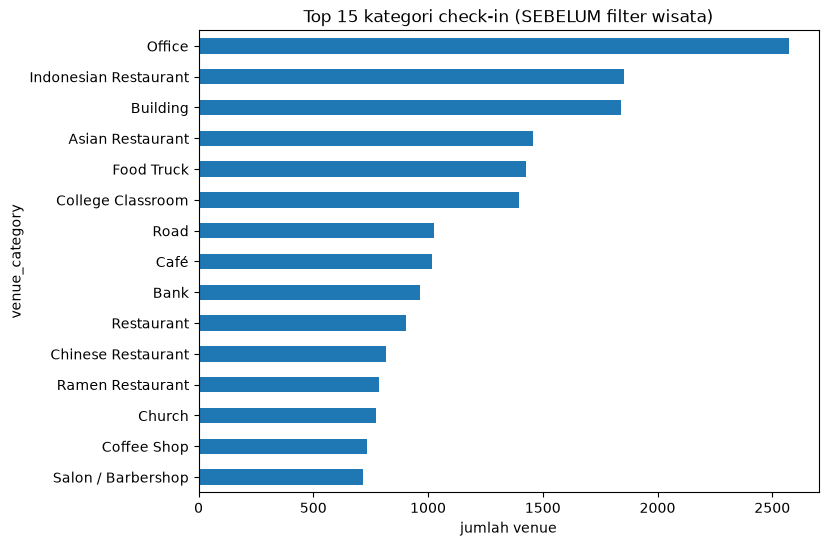

In [11]:
venues_steps["venue_category"].value_counts().head(15).plot(
    kind="barh", figsize=(8, 6), title="Top 15 kategori check-in (SEBELUM filter wisata)")
plt.xlabel("jumlah venue")
plt.gca().invert_yaxis()
plt.show()

Catatan: kategori didominasi Office/Home/Building/Restaurant -- check-in
Foursquare-style umum, bukan khusus wisata. Filter ke kategori wisata
dilakukan di tahap berikutnya (`03_data_processing.ipynb`).